<a href="https://colab.research.google.com/github/litlig/notebooks/blob/main/2d_diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diffusion model from scratch with 2-D examples

### Problem framing

All images are sampled from a probability distribution in a high-dim space. To generate a image, we can directly model the prob. distribution. Diffusion models follows a differnt path: it models the trajectory of transforming a sample generated from a known distribution to the unknown image space.

Images tends to form manifold in high-dim space. A 256x256 image in 3 color channels have 3x256x256 dimensions as the initial input. For illustration purpose, we say that the image have two pixels in a continous grey scale, then we can plot the distribution of all images in a 2-dim chart.

Below we show two imagionary distributions of image; every point on the line is a image, points off the line are interpreted as noise.

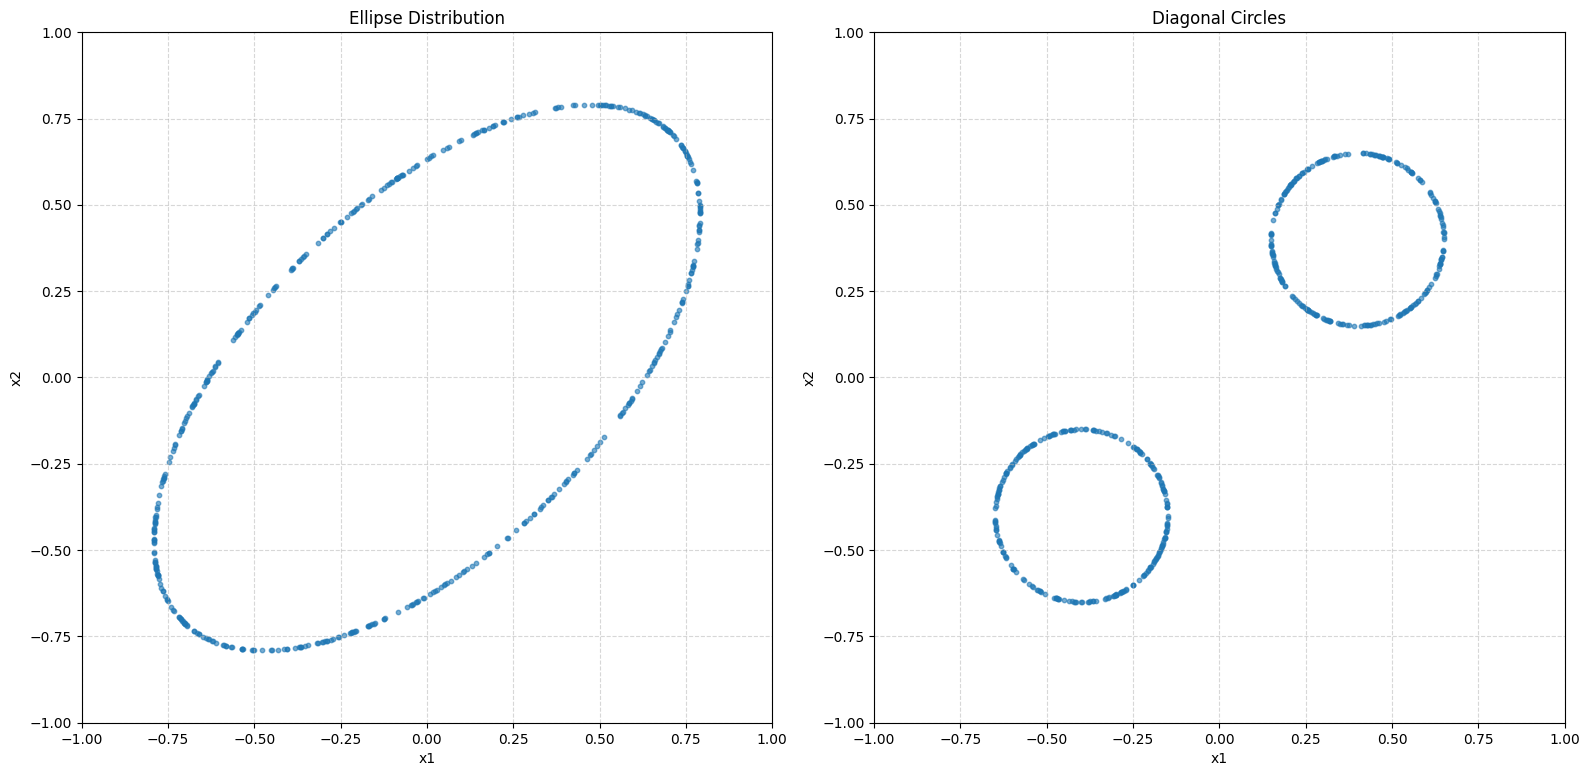

In [16]:
# @title 2D distribution examples
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, Tuple

def ellipse_distribution(batch_size: int = 1) -> np.ndarray:
  t = 2 * np.pi * np.random.rand(batch_size)
  theta_rad = np.pi / 4

  # Parametric equations for the ellipse
  x1 = 1.0 * np.cos(t)
  x2 = 0.5 * np.sin(t)

  # Apply rotation
  x1_rot = x1 * np.cos(theta_rad) - x2 * np.sin(theta_rad)
  x2_rot = x1 * np.sin(theta_rad) + x2 * np.cos(theta_rad)

  # Keep it zero-centered to match noise distribution
  return np.stack([x1_rot, x2_rot], axis=-1)

def diagonal_circles_distribution(batch_size: int = 1) -> np.ndarray:
  # Create two circles
  n_per_circle = batch_size // 2
  t = 2 * np.pi * np.random.rand(batch_size)
  r = 0.25

  centers = np.zeros((batch_size, 2))
  centers[:n_per_circle, :] = -0.4
  centers[n_per_circle:, :] = 0.4

  x1 = centers[:, 0] + r * np.cos(t)
  x2 = centers[:, 1] + r * np.sin(t)

  return np.stack([x1, x2], axis=-1)

def plot_side_by_side(dist1_fn, dist2_fn):
  fig, axes = plt.subplots(1, 2, figsize=(16, 8))
  for ax, fn, title in zip(axes, [dist1_fn, dist2_fn], ['Ellipse Distribution', 'Diagonal Circles']):
    samples = fn(500)
    ax.scatter(samples[:, 0], samples[:, 1], alpha=0.6, s=10)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title(title)
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_aspect('equal')
  plt.tight_layout()
  plt.show()

plot_side_by_side(ellipse_distribution, diagonal_circles_distribution)

### Flow Matching
Imagine we start with a sample of pure white noise $x_0$ and we want to reach a specific data point $z$ (the 'image') at time $t=1$. We can define a **probability path** $x_t$ that connects noise to data:

$$x_t = a_tx_0 + b_tz$$

Where $a_t$ and $b_t$ are **noise schedulers** with the following boundary conditions:
* At $t=0$: $a_0=1, b_0=0$ (Pure noise)
* At $t=1$: $a_1=0, b_1=1$ (Pure data)

#### Objective
The goal is to learn a **vector field** $v(x_t, t)$ that describes the 'velocity' or direction of this trajectory; it is the derivative of $x_t$ with respect to t. If we know the vector field, we can gradually move $x_t$ towards the target z using Euler method: $x_{t+h} = x_t + v_t h$.

When targe z is given, the conditional vector field has closed-form formula:

$$v_t(x|z) = \dot{a_t}x_0 + \dot{b_t}z$$

To get the un-conditional vector field, or the average vector field at a given point $x_t$ for all possible $z$, we need to take the integral over the distribution of z given $x_t$. We can further transform the math form using Bayes theory, and it's proved that: minimizing the mean squared error against the **conditional** vector field $v_t(x|z)$ is equivalent to minimizing it against the **marginal** vector field. We train a neural network $f(x_t, t, \theta)$ using the following objective:

$$\min_{\theta} \mathbb{E}_{t, q(z), p(x_0)} \| f(x_t, t, \theta) - v_t(x_t|z) \|^2$$

By regressing against the simple-to-calculate $v_t(x|z)$, the model implicitly learns to follow the complex marginal flow of the data distribution.

In [17]:
# @title Train a nn to estimate the vector field
import torch
import torch.nn as nn
import torch.nn.functional as F

def get_batch(dist_fn, batch_size):
  z = torch.from_numpy(dist_fn(batch_size)).float()
  x0 = torch.randn(batch_size, 2)
  t = torch.rand(batch_size, 1)
  xt = (1-t) * x0 + t * z
  vf = z - x0
  return xt, t, vf

def loss_fn(dist_fn, model, batch_size):
  xt, t, vf = get_batch(dist_fn, batch_size)
  model_input = torch.cat([xt, t], dim=-1)
  vf_pred = model(model_input)
  return F.mse_loss(vf_pred, vf)

def train(dist_fn, num_epochs=10000, batch_size=256, lr=0.001, plot_loss=True):
  # Increased capacity: wider and deeper to handle multi-modality
  model = nn.Sequential(
    nn.Linear(3, 256),
    nn.SiLU(),
    nn.Linear(256, 256),
    nn.SiLU(),
    nn.Linear(256, 256),
    nn.SiLU(),
    nn.Linear(256, 2),
  )

  optimizer = torch.optim.Adam(model.parameters(), lr)
  losses = []

  for epoch in range(num_epochs):
    optimizer.zero_grad()
    loss = loss_fn(dist_fn, model, batch_size)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if epoch % 1000 == 0:
      print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

  if plot_loss:
    plt.figure(figsize=(8, 4))
    plt.plot(losses)
    plt.yscale('log')
    plt.title('Training Loss')
    plt.show()

  return model

print("Training for ellipse example...")
elip_model = train(ellipse_distribution, plot_loss=False)
print("Training for diagonal circles example...")
circ_model = train(diagonal_circles_distribution, plot_loss=False)

Training for ellipse example...
Epoch 0, Loss: 1.423846
Epoch 1000, Loss: 0.724292
Epoch 2000, Loss: 0.711136
Epoch 3000, Loss: 0.731938
Epoch 4000, Loss: 0.844248
Epoch 5000, Loss: 0.641975
Epoch 6000, Loss: 0.747228
Epoch 7000, Loss: 0.755052
Epoch 8000, Loss: 0.743824
Epoch 9000, Loss: 0.665583
Training for diagonal circles example...
Epoch 0, Loss: 1.242918
Epoch 1000, Loss: 0.504431
Epoch 2000, Loss: 0.657016
Epoch 3000, Loss: 0.594699
Epoch 4000, Loss: 0.568228
Epoch 5000, Loss: 0.635645
Epoch 6000, Loss: 0.693150
Epoch 7000, Loss: 0.571269
Epoch 8000, Loss: 0.562979
Epoch 9000, Loss: 0.570473


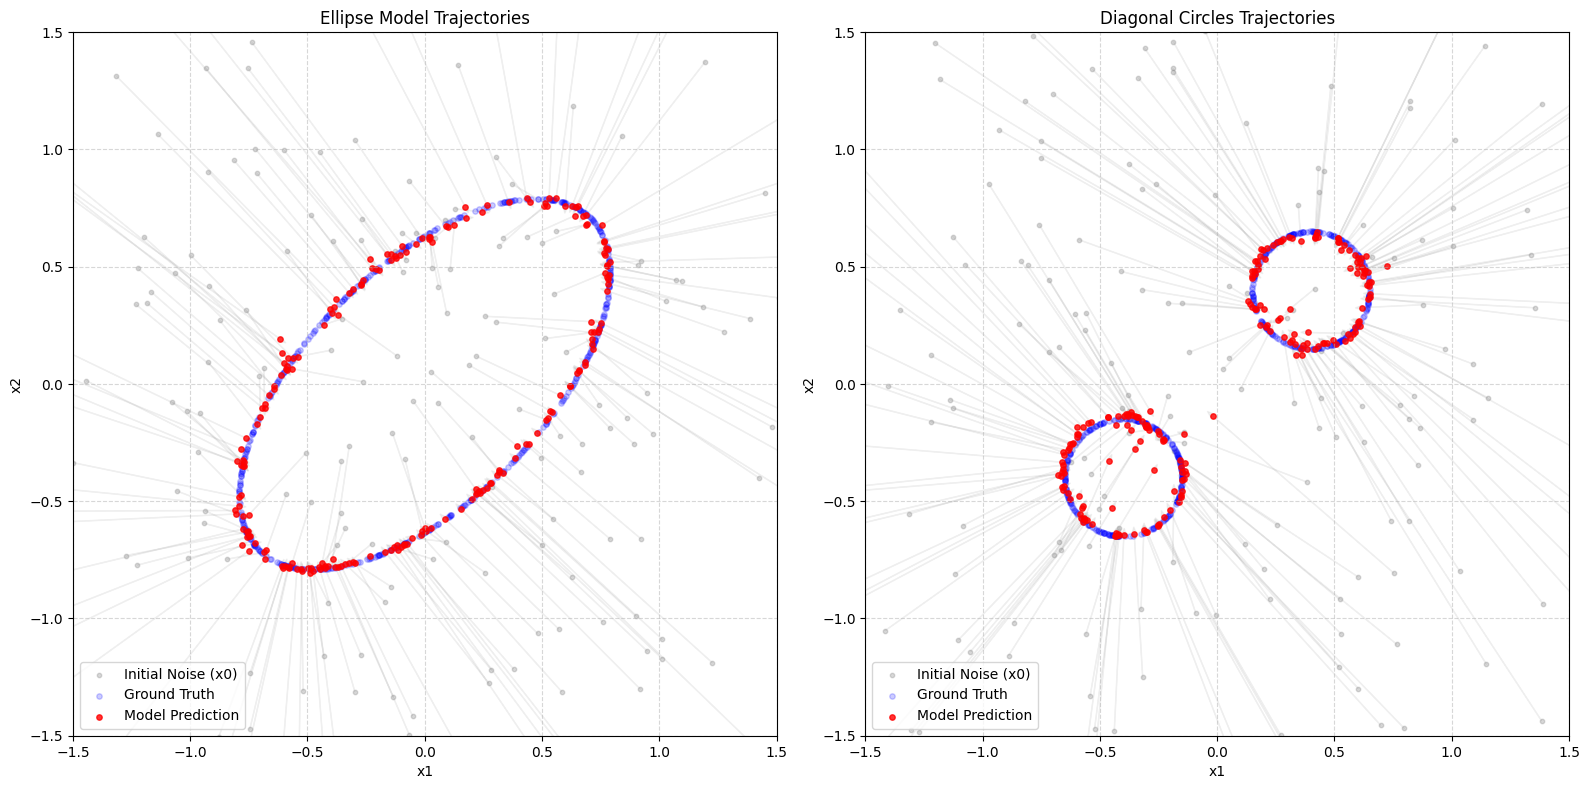

In [18]:
# @title sampling using trained nn
def sample_with_noise(model, nsample, steps=100):
  model.eval()
  with torch.no_grad():
    x_0 = torch.randn(nsample, 2)
    x = x_0.clone()
    dt = 1.0 / steps
    for step in range(steps):
      t = (step / steps) * torch.ones(nsample, 1)
      model_input = torch.cat([x, t], dim=-1)
      vf = model(model_input)
      x = x + vf * dt
  return x_0.cpu().numpy(), x.cpu().numpy()

def compare_all_results(elip_model, circ_model, n_samples=200): # Reduced n_samples for arrow clarity
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Plot Ellipse Results
    gt_elip = ellipse_distribution(500)
    noise_elip, pred_elip = sample_with_noise(elip_model, n_samples)

    # Draw arrows
    for i in range(n_samples):
        axes[0].arrow(noise_elip[i, 0], noise_elip[i, 1],
                      pred_elip[i, 0] - noise_elip[i, 0],
                      pred_elip[i, 1] - noise_elip[i, 1],
                      color='grey', alpha=0.1, head_width=0.02)

    axes[0].scatter(noise_elip[:, 0], noise_elip[:, 1], alpha=0.3, s=10, label='Initial Noise (x0)', color='grey')
    axes[0].scatter(gt_elip[:, 0], gt_elip[:, 1], alpha=0.2, s=15, label='Ground Truth', color='blue')
    axes[0].scatter(pred_elip[:, 0], pred_elip[:, 1], alpha=0.8, s=15, label='Model Prediction', color='red')
    axes[0].set_title('Ellipse Model Trajectories')
    axes[0].legend()

    # Plot Circle Results
    gt_circ = diagonal_circles_distribution(500)
    noise_circ, pred_circ = sample_with_noise(circ_model, n_samples)

    # Draw arrows
    for i in range(n_samples):
        axes[1].arrow(noise_circ[i, 0], noise_circ[i, 1],
                      pred_circ[i, 0] - noise_circ[i, 0],
                      pred_circ[i, 1] - noise_circ[i, 1],
                      color='grey', alpha=0.1, head_width=0.02)

    axes[1].scatter(noise_circ[:, 0], noise_circ[:, 1], alpha=0.3, s=10, label='Initial Noise (x0)', color='grey')
    axes[1].scatter(gt_circ[:, 0], gt_circ[:, 1], alpha=0.2, s=15, label='Ground Truth', color='blue')
    axes[1].scatter(pred_circ[:, 0], pred_circ[:, 1], alpha=0.8, s=15, label='Model Prediction', color='red')
    axes[1].set_title('Diagonal Circles Trajectories')
    axes[1].legend()

    for ax in axes:
        ax.set_xlabel('x1')
        ax.set_ylabel('x2')
        ax.set_xlim([-1.5, 1.5])
        ax.set_ylim([-1.5, 1.5])
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.set_aspect('equal')

    plt.tight_layout()
    plt.show()

compare_all_results(elip_model, circ_model)


As shown by the trajectory diagram above, flow matching is moving the noise points towards the closest image points in terms of Euclidean distance. Taking a look at the training sample we use: we randomly pick a image from the image collection, then $x_0$ is sampled from a Gaussian $N(0, I)$, and t is sampled from unifrom distribution from 0 to 1. Why would $x_0$ converges to the closest z, after training on a dataset that shows no such bias or tendency?
```
def get_batch(dist_fn, batch_size):
  z = torch.from_numpy(dist_fn(batch_size)).float()
  x0 = torch.randn(batch_size, 2)
  t = torch.rand(batch_size, 1)
  xt = (1-t) * x0 + t * z
  vf = z - x0
  return xt, t, vf
```
The reason is even though $x_0$ is unbiased, the model is taking $x_t$ as input and it has info on which z is more likely. At $t=0$, $x_t$ is pure noise and $p(z|x_t)$ are the same as the priori, so $x_t$ is drawn to the center of probabilty mass. When $t>0$,  $x_t$ starts to encode which z is more possile, and $p(z|x_t)$ are larger for z that's closer, so $x_t$ is drawn closer to these points.


### Diffusion models
With flow matching and vector field, the sampling path becomes determistic once the inital noise sample is drawn, and any error in the estimated vector field accumulates along the path and pushes the sample off the data manifold, yielding a poor image. Diffusion models inject noise at every sample step, which allows the path re-explore and re-converge towards high-probability regions. The forward samplign takes the form: $x_{t+h} = x_t + driftingCoefficient * h + diffusionCoefficient * noise$

With the additional diffusion term, to keep $x_t$ still follows $p_t$ as in the flow model, the drifting cofficient is the vector field in flow model and a score correction. The score correction term is typically derived from the gradient of the log-probability density function (the 'score') of the data distribution, which guides the noisy samples towards regions of higher probability, counteracting the effect of the injected noise.

In Gaussian propability path, both vector field and score are linear combination of $x_t$ and $z$, meaning score can be recovered from vector field and vice versa.

Below without training a diffusion model, we use the previous trained vector field to calculate score and forward sample following a diffusion path.

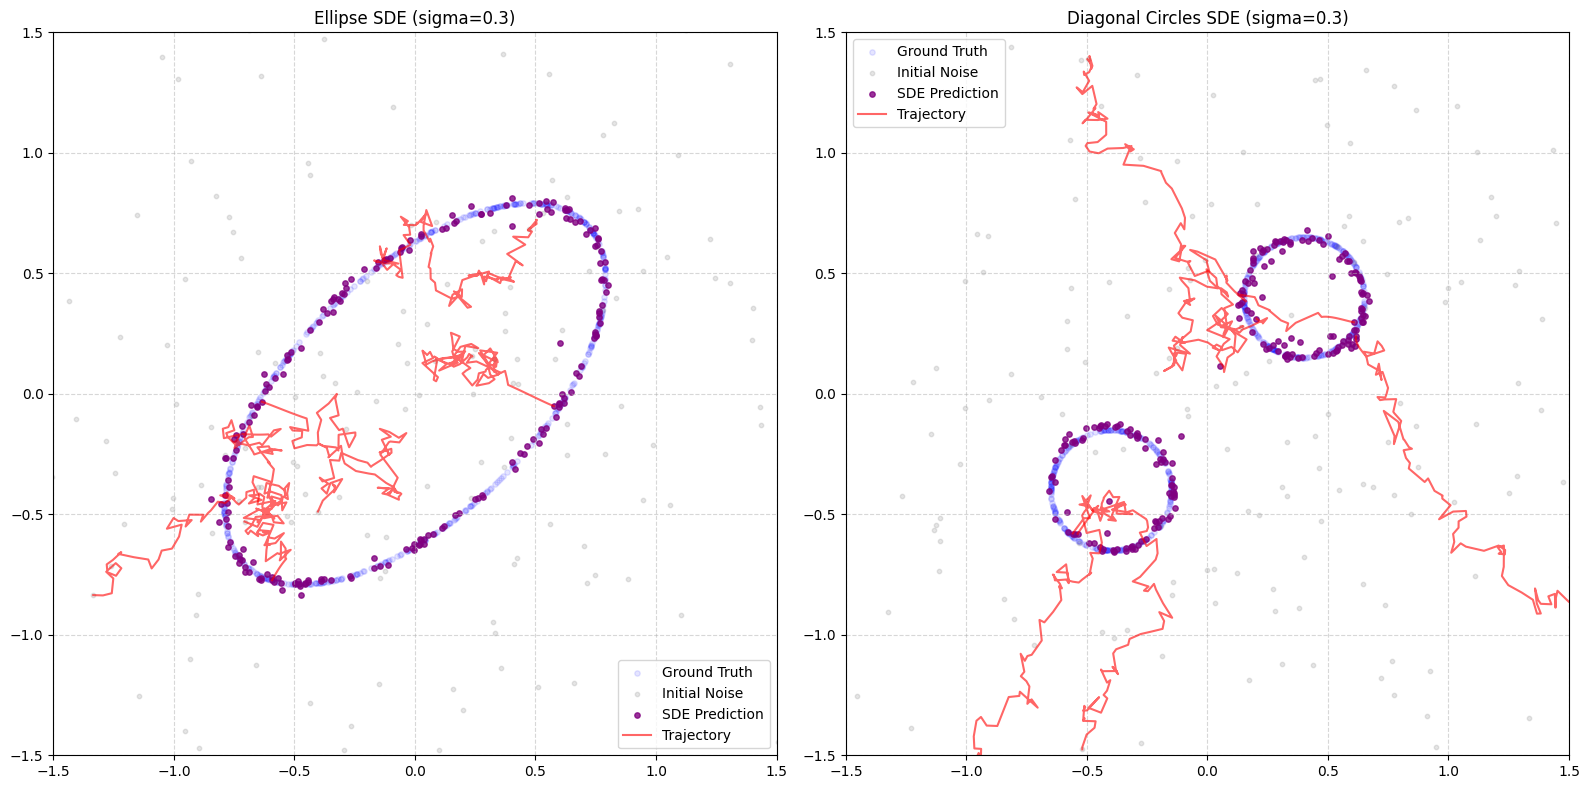

In [32]:
# @title sampling with added diffusion using the preivous trained vector field
def sample_sde_with_trajectories(model, nsample, steps=100, sigma=0.3, noise_off_after=0.9):
    model.eval()
    with torch.no_grad():
        x = torch.randn(nsample, 2)
        x_0 = x.clone()
        traj = [x.cpu().numpy().copy()]
        dt = 1.0 / steps
        for step in range(steps):
            t_val = step / steps
            t = t_val * torch.ones(nsample, 1)
            vf = model(torch.cat([x, t], dim=-1))
            sf = (t * vf - x) / torch.clamp(1 - t, min=1e-4)   # score
            s = sigma if t_val < noise_off_after else 0.0       # stop noise near t=1
            drift = vf + 0.5 * s**2 * sf                        # <-- (σ²/2)·score
            x = x + drift * dt + s * np.sqrt(dt) * torch.randn_like(x)
            traj.append(x.cpu().numpy().copy())
    return x_0.cpu().numpy(), x.cpu().numpy(), np.array(traj)

def compare_sde_results_with_traj(elip_model, circ_model, n_samples=200, sigma=0.1, n_traj=5):
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    for i, (model, dist_fn, title) in enumerate([(elip_model, ellipse_distribution, 'Ellipse'), (circ_model, diagonal_circles_distribution, 'Diagonal Circles')]):
        gt = dist_fn(500)
        noise, pred, trajs = sample_sde_with_trajectories(model, n_samples, sigma=sigma)

        # Plot ground truth and endpoints
        axes[i].scatter(gt[:, 0], gt[:, 1], alpha=0.1, s=15, label='Ground Truth', color='blue')
        axes[i].scatter(noise[:, 0], noise[:, 1], alpha=0.2, s=10, label='Initial Noise', color='grey')
        axes[i].scatter(pred[:, 0], pred[:, 1], alpha=0.8, s=15, label='SDE Prediction', color='purple')

        # Plot a few specific trajectories
        for j in range(n_traj):
            axes[i].plot(trajs[:, j, 0], trajs[:, j, 1], color='red', alpha=0.6, linewidth=1.5, label='Trajectory' if j==0 else "")

        axes[i].set_title(f'{title} SDE (sigma={sigma})')
        axes[i].set_xlim([-1.5, 1.5]); axes[i].set_ylim([-1.5, 1.5])
        axes[i].grid(True, linestyle='--', alpha=0.5)
        axes[i].set_aspect('equal')
        axes[i].legend()

    plt.tight_layout()
    plt.show()

compare_sde_results_with_traj(elip_model, circ_model, sigma=0.3)


=== Ellipse  (steps=10) ===
sampler        mean dist→GT ↓
 ODE (σ=0)              0.0323
 SDE (σ=0.2)            0.0364


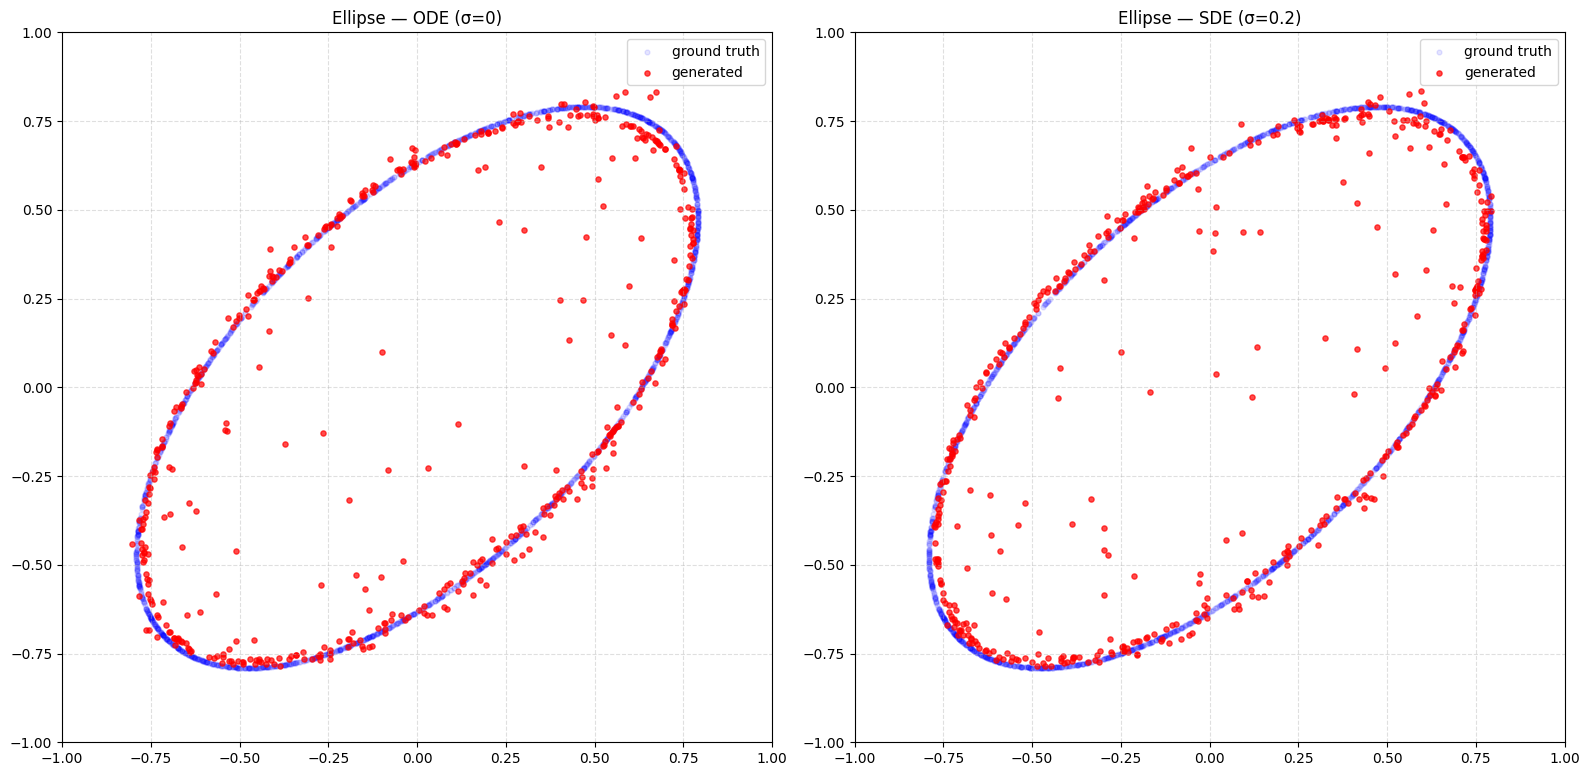


=== Diagonal circles  (steps=10) ===
sampler        mean dist→GT ↓   mode balance
 ODE (σ=0)              0.0512   48% / 52%
 SDE (σ=0.2)            0.0476   48% / 52%


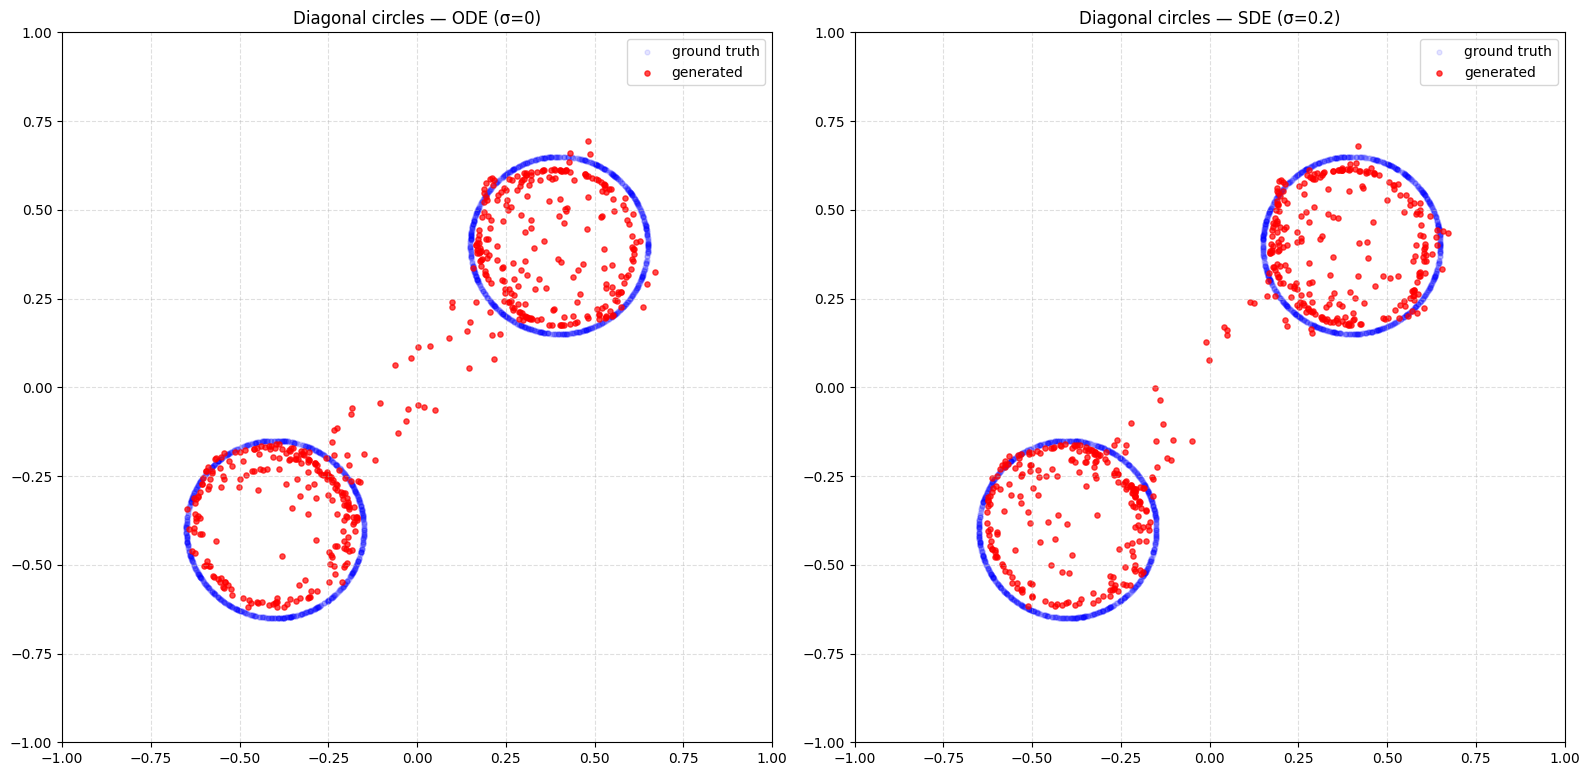

In [35]:
# @title Compare deterministic (ODE) vs stochastic (SDE) sampling — same field, same x0
import numpy as np
import torch
import matplotlib.pyplot as plt

def _nearest_gt_dist(gen, gt):
    # mean distance from each generated point to its nearest ground-truth point
    # (precision / "how tightly on-manifold"); lower is better
    d = np.sqrt(((gen[:, None, :] - gt[None, :, :]) ** 2).sum(-1))
    return d.min(axis=1).mean()

def _mode_balance(gen, centers):
    c = np.asarray(centers, dtype=np.float32)
    assign = np.argmin(((gen[:, None, :] - c[None, :, :]) ** 2).sum(-1), axis=1)
    return [float(np.mean(assign == k)) for k in range(len(c))]

def compare_samplers(model, dist_fn, steps=10, sigma=0.3, n_samples=500,
                     mode_centers=None, seed=0, title=""):
    gt = dist_fn(2000)

    # Shared initial noise: both samplers draw x0
    # so seeding identically makes x0 identical across ODE and SDE.
    torch.manual_seed(seed)
    x0_ode, ode = sample_with_noise(model, n_samples, steps=steps)
    torch.manual_seed(seed)
    # Changed sample_sde to sample_sde_with_trajectories
    x0_sde, sde, _ = sample_sde_with_trajectories(model, n_samples, steps=steps, sigma=sigma)
    assert np.allclose(x0_ode, x0_sde), "x0 mismat0 first"

    runs = [("ODE (σ=0)", ode), (f"SDE (σ={sigma})", sde)] # Fixed: added closing quote and parenthesis

    # --- metrics table ---
    # Fixed SyntaxWarning: concatenated f-strings correctly
    print(f"\n=== {title or dist_fn.__name__}  (steps={steps}) ===")
    print(f"{'sampler':<13}{'mean dist→GT ↓':>16}{'   mode balance' if mode_centers is not None else ''}")
    for name, s in runs:
        line = f" {name:<13}{_nearest_gt_dist(s, gt):>16.4f}"
        if mode_centers is not None:
            bal = _mode_balance(s, mode_centers)
            line += "   " + " / ".join(f"{b:.0%}" for b in bal)
        print(line)

    # --- overlay plot ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    for ax, (name, s) in zip(axes, runs):
        ax.scatter(gt[:, 0], gt[:, 1], s=12, alpha=0.1, color="blue", label="ground truth")
        ax.scatter(s[:, 0], s[:, 1], s=14, alpha=0.7, color="red", label="generated")
        ax.set_title(f"{title} — {name}")
        ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_aspect("equal")
        ax.grid(True, ls="--", alpha=0.4); ax.legend()
    plt.tight_layout(); plt.show()

# --- usage ---
compare_samplers(elip_model, ellipse_distribution,
                 steps=10, sigma=0.2, title="Ellipse")
compare_samplers(circ_model, diagonal_circles_distribution,
                 steps=10, sigma=0.2, mode_centers=[(-0.4, -0.4), (0.4, 0.4)],
                 title="Diagonal circles")